In [28]:
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt

In [51]:
df = pd.read_csv("../DataSets/List of Countries by Sugarcane Production.csv")

In [52]:
df.head()

,Unnamed: 0,Country,Continent,Production (Tons),Production per Person (Kg),Acreage (Hectare),Yield (Kg / Hectare)
0,0,Brazil,South America,768.678.382,"3.668,531",10.226.205,"75.167,5"
1,1,India,Asia,348.448.000,260721,4.950.000,"70.393,5"
2,2,China,Asia,123.059.739,88287,1.675.215,"73.459,1"
3,3,Thailand,Asia,87.468.496,"1.264,303",1.336.575,"65.442,2"
4,4,Pakistan,Asia,65.450.704,324219,1.130.820,57.879


In [53]:
df.shape

(103, 7)

# Data Cleaning

In [54]:
df["Production (Tons)"] = df["Production (Tons)"].str.replace(".","")
df["Production per Person (Kg)"] = df["Production per Person (Kg)"].str.replace(".","").str.replace(",",".")
df["Acreage (Hectare)"] = df["Acreage (Hectare)"].str.replace(".","")
df["Yield (Kg / Hectare)"]= df["Yield (Kg / Hectare)"].str.replace(".","").str.replace(",",".")

In [55]:
df.isna().sum()

Unnamed: 0                    0
Country                       0
Continent                     0
Production (Tons)             0
Production per Person (Kg)    0
Acreage (Hectare)             1
Yield (Kg / Hectare)          1
dtype: int64

In [56]:
df[df["Acreage (Hectare)"].isna()]

,Unnamed: 0,Country,Continent,Production (Tons),Production per Person (Kg),Acreage (Hectare),Yield (Kg / Hectare)
99,99,Djibouti,Africa,53,51,NaN,NaN


In [57]:
df = df.dropna().reset_index()

In [58]:
df.isna().sum()

index                         0
Unnamed: 0                    0
Country                       0
Continent                     0
Production (Tons)             0
Production per Person (Kg)    0
Acreage (Hectare)             0
Yield (Kg / Hectare)          0
dtype: int64

In [59]:
df.drop(["Unnamed: 0"], axis=1, inplace=True)

In [60]:
df.head()

,index,Country,Continent,Production (Tons),Production per Person (Kg),Acreage (Hectare),Yield (Kg / Hectare)
0,0,Brazil,South America,768678382,3668.531,10226205,75167.5
1,1,India,Asia,348448000,260721,4950000,70393.5
2,2,China,Asia,123059739,88287,1675215,73459.1
3,3,Thailand,Asia,87468496,1264.303,1336575,65442.2
4,4,Pakistan,Asia,65450704,324219,1130820,57879


In [61]:
df.dtypes

index                          int64
Country                       object
Continent                     object
Production (Tons)             object
Production per Person (Kg)    object
Acreage (Hectare)             object
Yield (Kg / Hectare)          object
dtype: object

In [62]:
df.head()

,index,Country,Continent,Production (Tons),Production per Person (Kg),Acreage (Hectare),Yield (Kg / Hectare)
0,0,Brazil,South America,768678382,3668.531,10226205,75167.5
1,1,India,Asia,348448000,260721,4950000,70393.5
2,2,China,Asia,123059739,88287,1675215,73459.1
3,3,Thailand,Asia,87468496,1264.303,1336575,65442.2
4,4,Pakistan,Asia,65450704,324219,1130820,57879


In [63]:
df.rename(columns= {"Production (Tons)": "Production(Tons)"}, inplace = True)
df.rename(columns= {"Production per Person (Kg)": "Production_per_person(Kg)"}, inplace = True)
df.rename(columns= {"Acreage (Hectare)": "Acreage(Hectare)"}, inplace = True)
df.rename(columns= {"Yield (Kg / Hectare)": "Yield(Kg/Hectare)"}, inplace = True)

In [64]:
df["Production(Tons)"] = df["Production(Tons)"].astype(float)
df["Production_per_person(Kg)"] = df["Production_per_person(Kg)"].astype(float)
df["Acreage(Hectare)"] = df["Acreage(Hectare)"].astype(float)
df["Yield(Kg/Hectare)"]= df["Yield(Kg/Hectare)"].astype(float)

In [65]:
df.nunique()

index                        102
Country                      102
Continent                      6
Production(Tons)             102
Production_per_person(Kg)    101
Acreage(Hectare)             101
Yield(Kg/Hectare)            102
dtype: int64

# Univariate Analysis

In [71]:
df.head()

,index,Country,Continent,Production(Tons),Production_per_person(Kg),Acreage(Hectare),Yield(Kg/Hectare)
0,0,Brazil,South America,768678382.0,3668.531,10226205.0,75167.5
1,1,India,Asia,348448000.0,260721.000,4950000.0,70393.5
2,2,China,Asia,123059739.0,88287.000,1675215.0,73459.1
3,3,Thailand,Asia,87468496.0,1264.303,1336575.0,65442.2
4,4,Pakistan,Asia,65450704.0,324219.000,1130820.0,57879.0


In [73]:
df.describe()

,index,Production(Tons),Production_per_person(Kg),Acreage(Hectare),Yield(Kg/Hectare)
count,102.000000,1.020000e+02,102.000000,1.020000e+02,102.000000
mean,50.529412,1.850372e+07,112952.435755,2.498981e+05,52628.078431
std,29.638985,8.419149e+07,176651.341929,1.137003e+06,30504.676683
min,0.000000,1.000000e+00,0.000000,0.000000e+00,10.000000
25%,25.250000,6.251875e+04,3671.910000,1.104000e+03,29072.025000
50%,50.500000,1.440044e+06,25572.500000,1.655800e+04,54108.950000
75%,75.750000,6.426824e+06,146384.750000,8.047400e+04,73282.700000
max,102.000000,7.686784e+08,951087.000000,1.022620e+07,129049.300000


### How many countries produce sugarcane from each continent? 

In [66]:
df["Continent"].value_counts()

Continent
Africa           38
Asia             25
North America    22
South America    11
Oceania           4
Europe            2
Name: count, dtype: int64

<Axes: xlabel='Continent'>

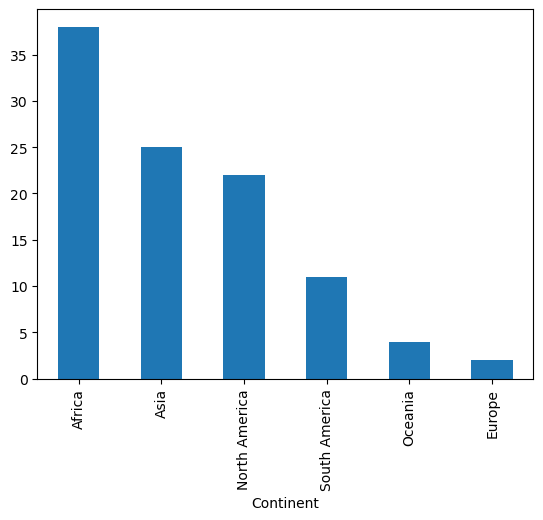

In [67]:
df["Continent"].value_counts().plot(kind="bar")

## Checking Outliers

C:\Users\HP\AppData\Local\Temp\ipykernel_25808\1574282873.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df["Production(Tons)"])
C:\Users\HP\AppData\Local\Temp\ipykernel_25808\1574282873.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df["Production_per_person(Kg)"])
C:\Users\HP\AppData

<Axes: xlabel='Yield(Kg/Hectare)', ylabel='Density'>

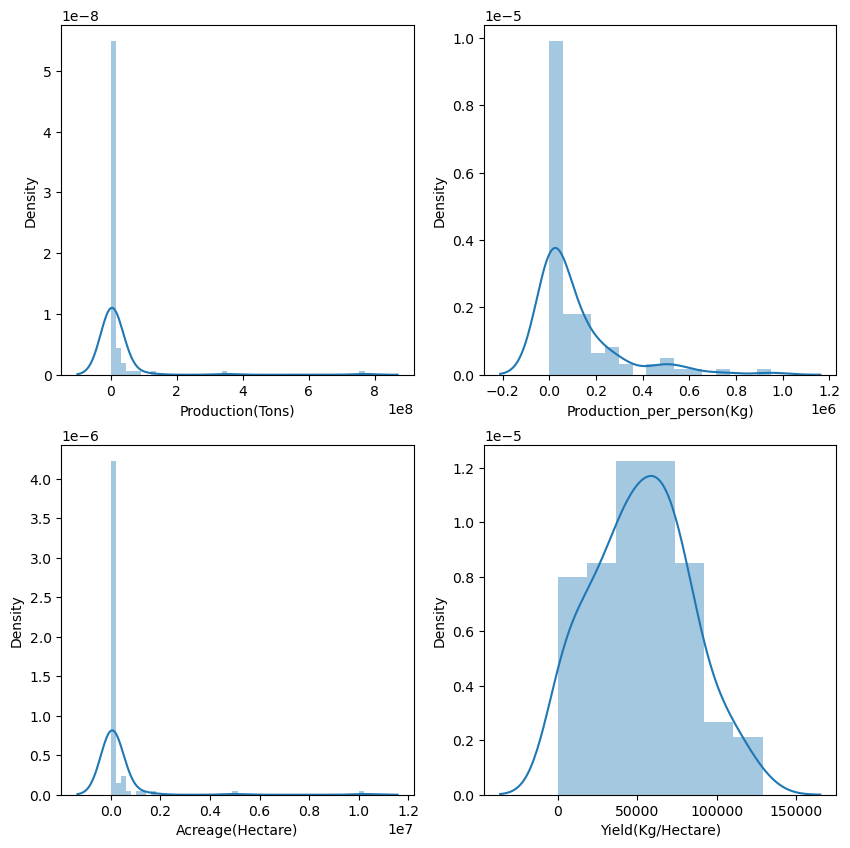

In [72]:
plt.figure(figsize=(10,10))
plt.subplot(2,2,1)
sns.distplot(df["Production(Tons)"])
plt.subplot(2,2,2)
sns.distplot(df["Production_per_person(Kg)"])
plt.subplot(2,2,3)
sns.distplot(df["Acreage(Hectare)"])
plt.subplot(2,2,4)
sns.distplot(df["Yield(Kg/Hectare)"])

<Axes: ylabel='Yield(Kg/Hectare)'>

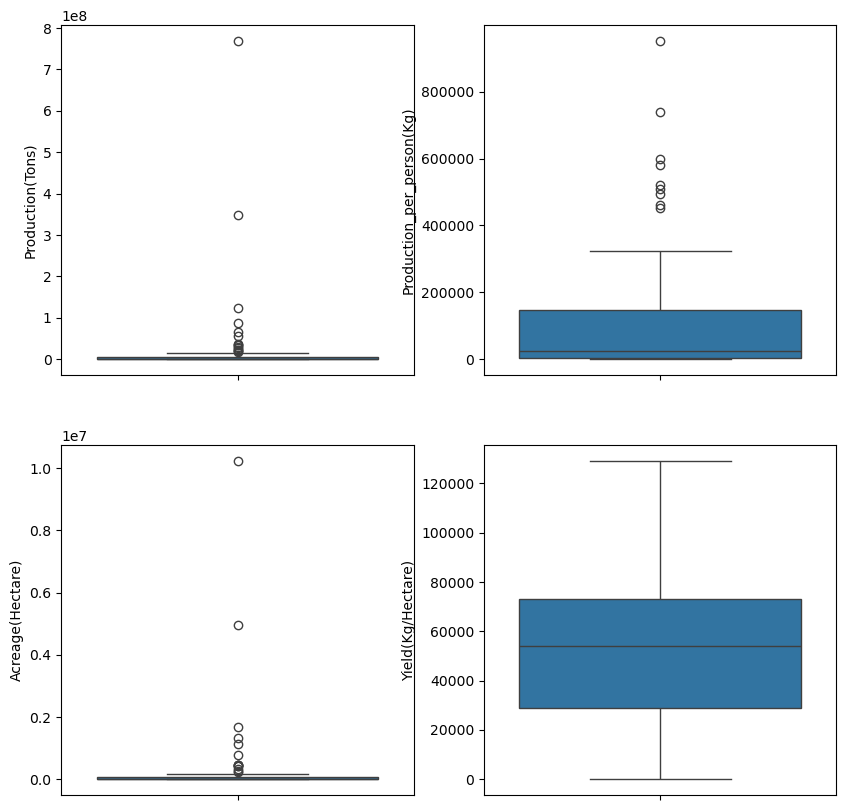

In [74]:
plt.figure(figsize=(10,10))
plt.subplot(2,2,1)
sns.boxplot(df["Production(Tons)"])
plt.subplot(2,2,2)
sns.boxplot(df["Production_per_person(Kg)"])
plt.subplot(2,2,3)
sns.boxplot(df["Acreage(Hectare)"])
plt.subplot(2,2,4)
sns.boxplot(df["Yield(Kg/Hectare)"])

# Bivariate Analysis

### Which country produces maximum sugarcane?

In [76]:
df_new = df[["Country", "Production(Tons)"]].set_index("Country")

In [77]:
df_new.head()

,Production(Tons)
Country,
Brazil,768678382.0
India,348448000.0
China,123059739.0
Thailand,87468496.0
Pakistan,65450704.0


In [78]:
df_new["Production(Tons)_percent"] = df_new["Production(Tons)"]*100 / df_new["Production(Tons)"].sum()

In [79]:
df_new

,Production(Tons),Production(Tons)_percent
Country,,
Brazil,768678382.0,4.072729e+01
India,348448000.0,1.846200e+01
China,123059739.0,6.520138e+00
Thailand,87468496.0,4.634389e+00
Pakistan,65450704.0,3.467809e+00
...,...,...
Spain,394.0,2.087551e-05
Lebanon,97.0,5.139401e-06
Singapore,50.0,2.649176e-06


<Axes: ylabel='Production(Tons)_percent'>

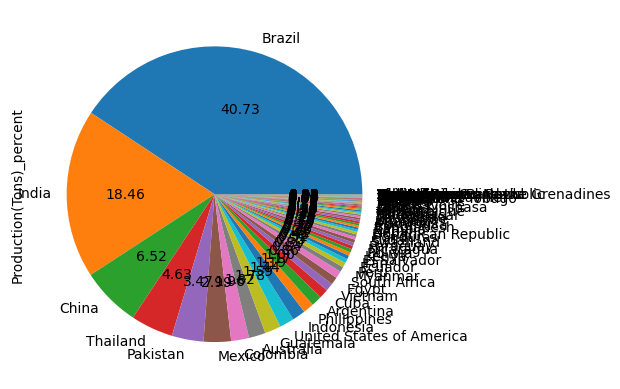

In [83]:
df_new["Production(Tons)_percent"].plot(kind = "pie", autopct="%.2f")

<Axes: xlabel='Country'>

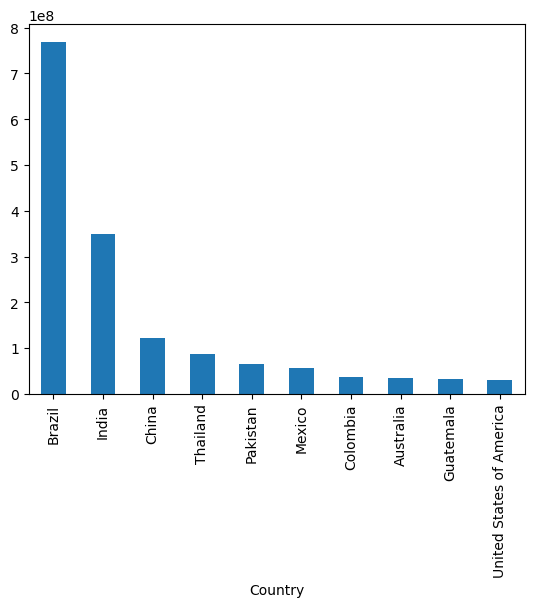

In [90]:
df_new["Production(Tons)"].head(10).plot(kind = "bar")

C:\Users\HP\AppData\Local\Temp\ipykernel_25808\1516096756.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  x = sns.barplot(data=df_prod.head(10), x = "Country", y="Production(Tons)", palette="deep")
C:\Users\HP\AppData\Local\Temp\ipykernel_25808\1516096756.py:3: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  x.set_xticklabels(x.get_xticklabels(), rotation = 90)


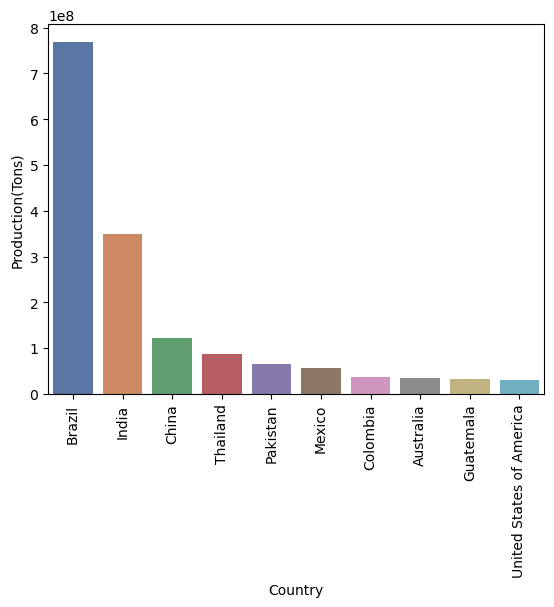

In [99]:
df_prod = df.sort_values("Production(Tons)", ascending=False)
x = sns.barplot(data=df_prod.head(10), x = "Country", y="Production(Tons)", palette="deep")
x.set_xticklabels(x.get_xticklabels(), rotation = 90)
plt.show()

### Which country has highest land?

C:\Users\HP\AppData\Local\Temp\ipykernel_25808\1104609520.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  x = sns.barplot(data=df_acr.head(10), x = "Country", y="Acreage(Hectare)", palette="deep")
C:\Users\HP\AppData\Local\Temp\ipykernel_25808\1104609520.py:3: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  x.set_xticklabels(x.get_xticklabels(), rotation = 90)


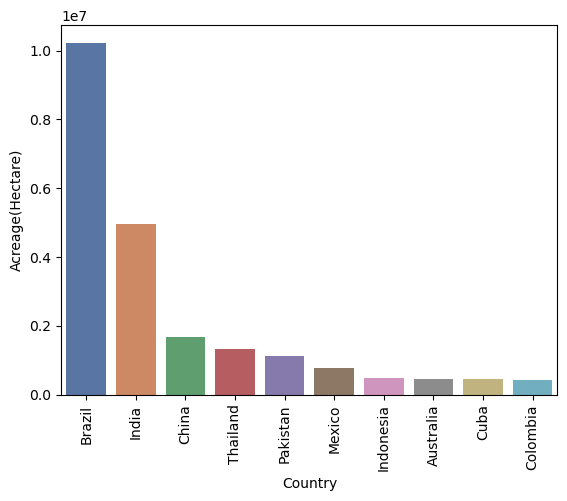

In [102]:
df_acr = df.sort_values("Acreage(Hectare)", ascending=False)
x = sns.barplot(data=df_acr.head(10), x = "Country", y="Acreage(Hectare)", palette="deep")
x.set_xticklabels(x.get_xticklabels(), rotation = 90)
plt.show()

### Which Country has highest Yield per Hectare?

C:\Users\HP\AppData\Local\Temp\ipykernel_25808\2188616481.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  x = sns.barplot(data=df_yield.head(10), x = "Country", y="Yield(Kg/Hectare)", palette="deep")
C:\Users\HP\AppData\Local\Temp\ipykernel_25808\2188616481.py:3: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  x.set_xticklabels(x.get_xticklabels(), rotation = 90)


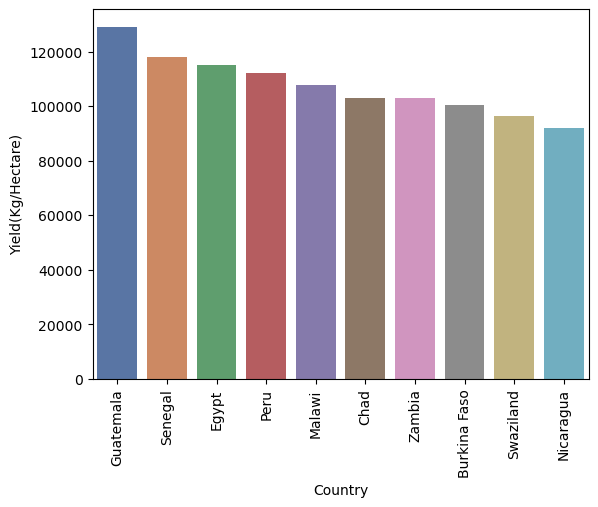

In [101]:
df_yield = df.sort_values("Yield(Kg/Hectare)", ascending=False)
x = sns.barplot(data=df_yield.head(10), x = "Country", y="Yield(Kg/Hectare)", palette="deep")
x.set_xticklabels(x.get_xticklabels(), rotation = 90)
plt.show()

### Which Country has highest Production per Person?

C:\Users\HP\AppData\Local\Temp\ipykernel_25808\3718861407.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  x = sns.barplot(data=df_pp.head(10), x = "Country", y="Production_per_person(Kg)", palette="deep")
C:\Users\HP\AppData\Local\Temp\ipykernel_25808\3718861407.py:3: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  x.set_xticklabels(x.get_xticklabels(), rotation = 90)


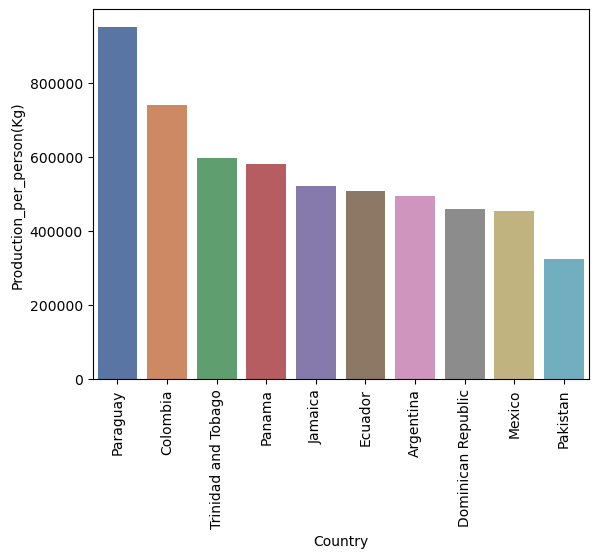

In [103]:
df_pp = df.sort_values("Production_per_person(Kg)", ascending=False)
x = sns.barplot(data=df_pp.head(10), x = "Country", y="Production_per_person(Kg)", palette="deep")
x.set_xticklabels(x.get_xticklabels(), rotation = 90)
plt.show()

# Correlation

In [133]:
numeric_df = df.select_dtypes(include=['int64', 'float64'])
numeric_df.corr()

,Production(Tons),Production_per_person(Kg),Acreage(Hectare),Yield(Kg/Hectare)
Production(Tons),1.000000,0.015000,0.997550,0.132812
Production_per_person(Kg),0.015000,1.000000,0.012557,0.017999
Acreage(Hectare),0.997550,0.012557,1.000000,0.113433
Yield(Kg/Hectare),0.132812,0.017999,0.113433,1.000000


<Axes: >

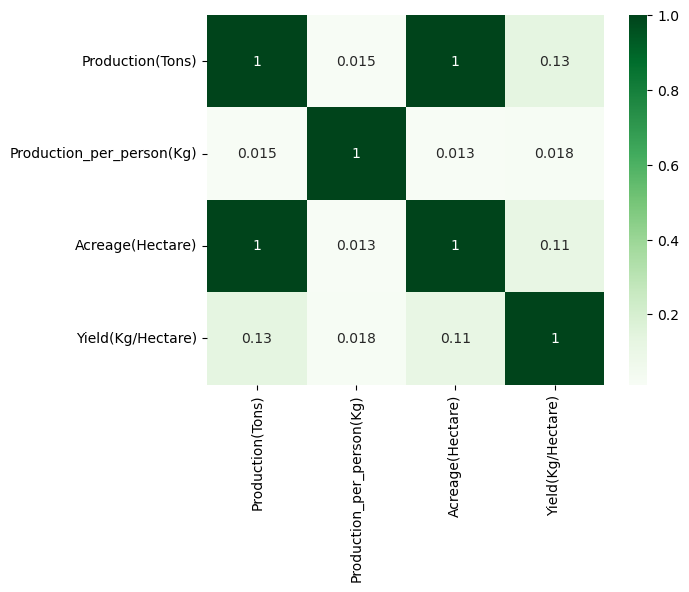

In [117]:
sns.heatmap(numeric_df.corr(), annot = True, cmap="Greens")

### Do countries with highest land produce more sugarcane?

<Axes: xlabel='Acreage(Hectare)', ylabel='Production(Tons)'>

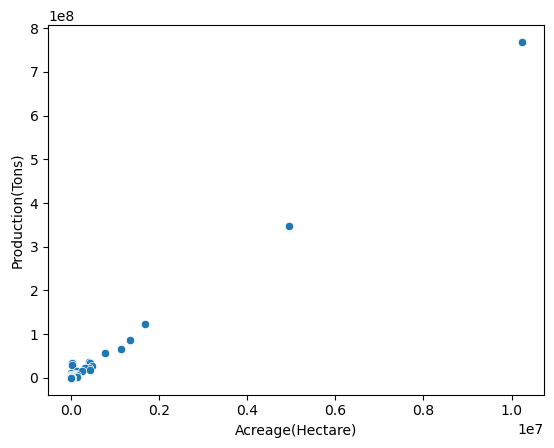

In [118]:
sns.scatterplot(data=df, x = "Acreage(Hectare)", y="Production(Tons)")

### Do countries which yield more sugarcane per hectare produces more sugarcane in total?

<Axes: xlabel='Yield(Kg/Hectare)', ylabel='Production(Tons)'>

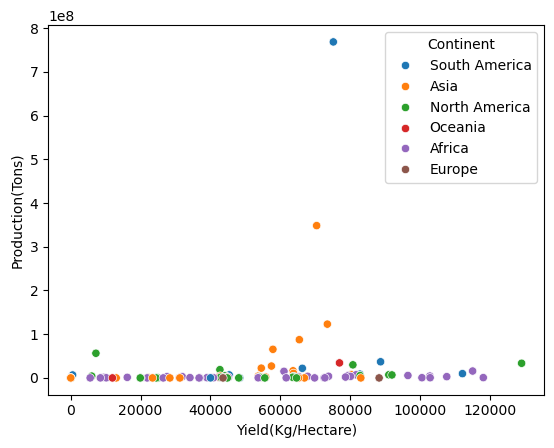

In [119]:
sns.scatterplot(data = df, x = "Yield(Kg/Hectare)" , y = "Production(Tons)", hue = "Continent")

## Analysis for Continent

In [130]:
df_continent = df.groupby("Continent").sum()
df_continent["number_of_countries"] = df.groupby("Continent").count()["Country"]
df_continent

,Country,Production(Tons),Production_per_person(Kg),Acreage(Hectare),Yield(Kg/Hectare),number_of_countries
Continent,,,,,,
Africa,EgyptSouth AfricaKenyaSwazilandSudanZambiaMaur...,89681472.0,2332636.293,1439089.0,2142107.5,38
Asia,IndiaChinaThailandPakistanIndonesiaPhilippines...,721930425.0,1857769.303,10608319.0,1171871.4,25
Europe,PortugalSpain,5823.0,536.000,71.0,131870.9,2
North America,MexicoGuatemalaUnited States of AmericaCubaEl ...,173995947.0,3796081.508,1581983.0,1082602.4,22
Oceania,AustraliaFijiPapua New GuineaSamoa,36177574.0,28593.605,490909.0,162419.1,4
South America,BrazilColombiaArgentinaPeruEcuadorBoliviaParag...,865588126.0,3505531.738,11369236.0,677192.7,11


### Which Continent produces maximum sugarcane?

<Axes: xlabel='Continent'>

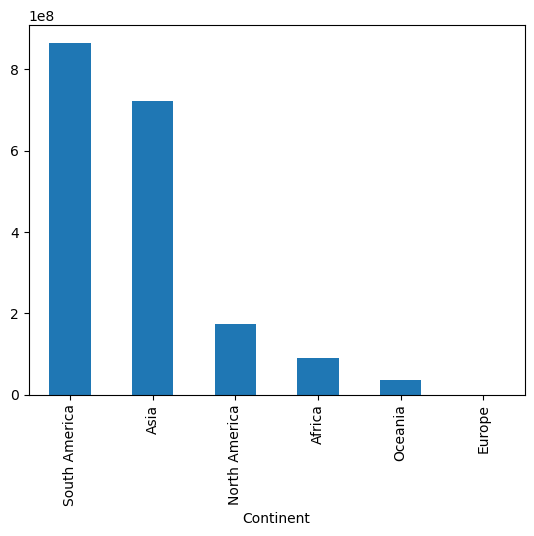

In [121]:
df_continent["Production(Tons)"].sort_values(ascending = False).plot(kind = "bar")

### Which Country has maximum land for sugarcane production?

<Axes: xlabel='Continent'>

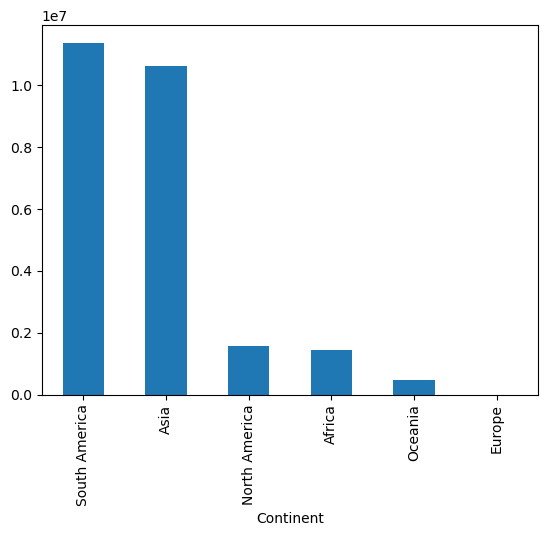

In [122]:
df_continent["Acreage(Hectare)"].sort_values(ascending = False).plot(kind = "bar")

### Do number of countries in a Continent effects production of sugarcane?

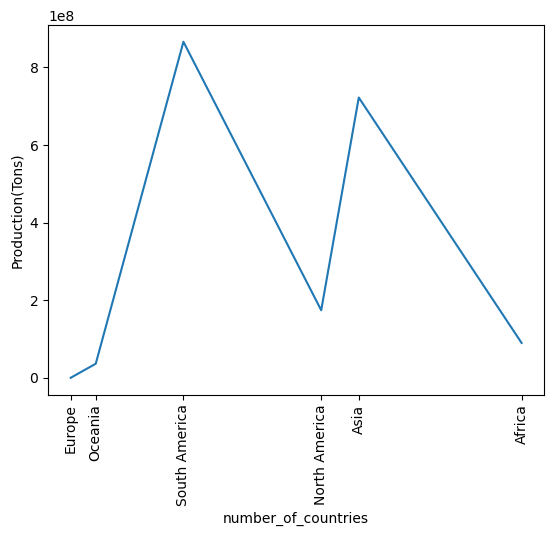

In [131]:
continent_names = df_continent.index.to_list()
sns.lineplot(data=df_continent, x = "number_of_countries", y="Production(Tons)")
plt.xticks(df_continent["number_of_countries"], continent_names, rotation=90)
plt.show()

### Do continent with highest land produces more sugarcane?

In [134]:
correlation = df_continent.select_dtypes(include=['int', 'float'])
correlation.corr()

,Production(Tons),Production_per_person(Kg),Acreage(Hectare),Yield(Kg/Hectare),number_of_countries
Production(Tons),1.000000,0.522211,0.994897,0.091201,0.109244
Production_per_person(Kg),0.522211,1.000000,0.463215,0.542961,0.540086
Acreage(Hectare),0.994897,0.463215,1.000000,0.111166,0.132817
Yield(Kg/Hectare),0.091201,0.542961,0.111166,1.000000,0.989712
number_of_countries,0.109244,0.540086,0.132817,0.989712,1.000000


<Axes: xlabel='Acreage(Hectare)', ylabel='Production(Tons)'>

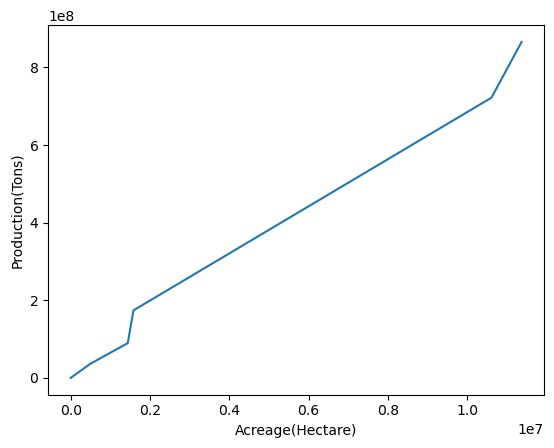

In [136]:
sns.lineplot(data=df_continent, x="Acreage(Hectare)", y = "Production(Tons)")

### Prouction Distribution by Continent

<Axes: ylabel='Production(Tons)'>

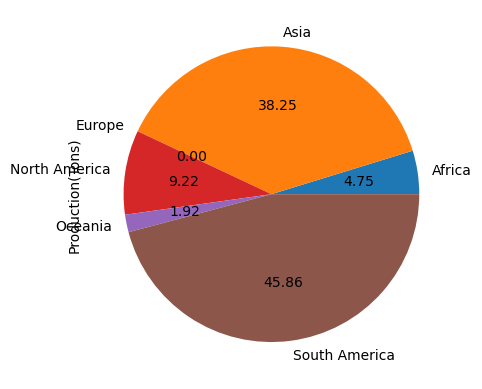

In [137]:
df_continent["Production(Tons)"].plot(kind="pie", autopct="%.2f")